In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from functools import partial
from einops import rearrange
from scipy.interpolate import RectBivariateSpline
from scipy.ndimage import gaussian_filter
from tqdm.notebook import tqdm

import sys
sys.path.append("../")

from utils import create_mask as cm
from utils.pdf_sampler import PDFSampler
from models.psf import KingPSF

%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pylab as pylab
import warnings
import matplotlib.cbook

from plot_params import params

warnings.filterwarnings("ignore",category=matplotlib.cbook.mplDeprecation)

pylab.rcParams.update(params)
cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [3]:
from reproject import reproject_from_healpix, reproject_to_healpix
from astropy.wcs import WCS
from astropy.coordinates import ICRS, Galactic

In [4]:
from utils.cart import make_wcs, to_cart

In [5]:
# from torchinfo import summary

In [6]:
cmap = 'RdBu_r'

In [7]:
! nvidia-smi

Thu Apr 21 15:58:28 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 470.57.02    Driver Version: 470.57.02    CUDA Version: 11.4     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla V100-PCIE...  On   | 00000000:2F:00.0 Off |                    0 |
| N/A   36C    P0    26W / 250W |      0MiB / 32510MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [8]:
extent = 25
n_pixels = 100
pixelsize = 2 * extent / n_pixels
upsample_factor = 4
nside = 128
sigma_psf = 0.2

In [9]:
fermi_data_cart = to_cart(np.load("../data/fermi_data/fermidata_counts.npy"), n_pixels=n_pixels, pixelsize=pixelsize)

# Load standard templates
temp_gce_cart = to_cart(np.load("../data/fermi_data/template_gce.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_dif_cart = to_cart(np.load("../data/fermi_data/template_dif.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_psc_cart = to_cart(np.load("../data/fermi_data/template_psc.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_iso_cart = to_cart(np.load("../data/fermi_data/template_iso.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_dsk_cart = to_cart(np.load("../data/fermi_data/template_dsk.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_bub_cart = to_cart(np.load("../data/fermi_data/template_bub.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
mask_ps = np.load("../data/fermi_data/fermidata_pscmask.npy") == 1

# Load Model O templates
temp_mO_pibrem_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_pibrem.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_mO_ics_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_ics.npy"), n_pixels=n_pixels, pixelsize=pixelsize)

mask_roi = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=60., custom_mask=mask_ps), n_pixels=n_pixels, pixelsize=pixelsize) > 0
# mask_roi = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=60.,), n_pixels=n_pixels, pixelsize=pixelsize) > 0


## Generative model

In [10]:
data = np.load("../data/samples/data_uniform.npz")
signal_ensemble = data["signal_ensemble"][:50000]
flux_fraction = data["flux_fraction"][:50000]

In [11]:
del data

In [12]:
from models.glow_module import GlowPL
import torch

In [13]:
x = torch.Tensor(signal_ensemble)[:, 2:-2, 2:-2].unsqueeze(1)

In [14]:
x.max()

tensor(2971.)

In [15]:
model = GlowPL(num_channels=256, num_levels=5, num_steps=18, quants=x.max(), add_unif_noise=False)

../models/glow.py:102: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at  ../torch/csrc/utils/tensor_numpy.cpp:178.)
  w_s = torch.from_numpy(w_s)


In [16]:
model.flow.load_state_dict(torch.load("../data/logs/wandb/latest-run/files/flow.ckpt"))
model.flow.eval();

In [17]:
def calc_z_shapes(n_channel=1, input_size=96, n_flow=18, n_block=5):
    z_shapes = []

    for i in range(n_block - 1):
        
        input_size //= 2
        n_channel *= 2

        z_shapes.append((n_channel, input_size, input_size))

    input_size //= 2
    z_shapes.append((n_channel * 4, input_size, input_size))

    return z_shapes

In [18]:
model.to('cuda');

In [19]:
from tqdm import tqdm

In [20]:
n_samples = 50

x_samples = []

for _ in tqdm(range(10)):
    z_sample = []
    z_shapes = calc_z_shapes()
    for z in z_shapes:
        z_new = torch.randn(n_samples, *z)
        z_sample.append(z_new.to('cuda'))

    x_samples_temp = (model.flow.reverse(z_sample, reconstruct=False, quant_int=True))
    x_samples.append(x_samples_temp)

100%|██████████| 10/10 [00:01<00:00,  6.32it/s]


In [21]:
x_samples = torch.cat(x_samples)
x_samples = x_samples.cpu()

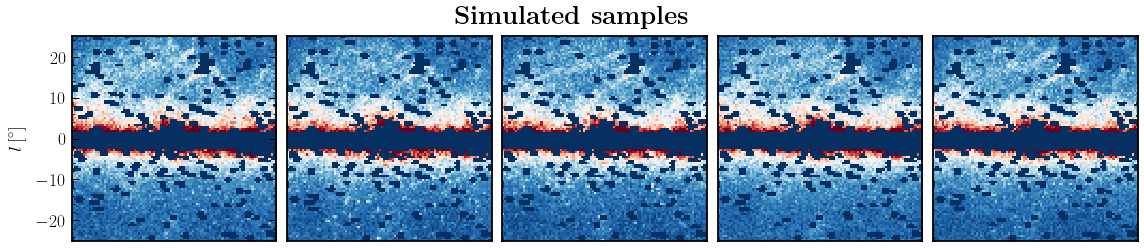

In [22]:
fig, axs = plt.subplots(1, 5, figsize=(16, 4))

for i, ax in enumerate(axs):
    ax.imshow(x[i,0].detach().numpy() * ~mask_roi[2:-2, 2:-2] , cmap=cmap, vmax=100, origin='lower', extent=[-25, 25, -25, 25])
    if i == 0:
        ax.set_ylabel(r"$l\,[^\circ]$")
        ax.get_xaxis().set_visible(False)
    if i != 0:
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

plt.suptitle(r"\textbf{Simulated samples}", fontsize=26, y=0.9)
plt.tight_layout()
plt.savefig("../paper/samples_sim.pdf")

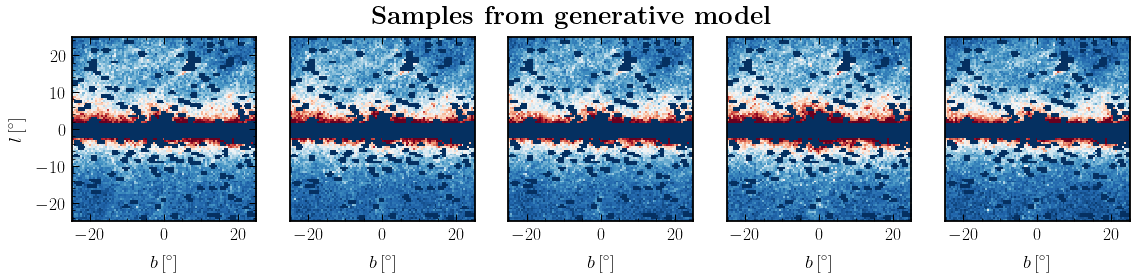

In [23]:
fig, axs = plt.subplots(1, 5, figsize=(16, 4))

for i, ax in enumerate(axs):
    ax.imshow(x_samples[i,0].detach().numpy() * ~mask_roi[2:-2, 2:-2], cmap=cmap, vmax=100, origin='lower', extent=[-25, 25, -25, 25])
    if i == 0:
        ax.set_ylabel(r"$l\,[^\circ]$")
        ax.set_xlabel(r"$b\,[^\circ]$")
    if i != 0:
        ax.set_xlabel(r"$b\,[^\circ]$")
        ax.get_yaxis().set_visible(False)

plt.suptitle(r"\textbf{Samples from generative model}", fontsize=26, y=0.9)
plt.tight_layout()
plt.savefig("../paper/samples_gen.pdf")

## Test summaries

In [24]:
from scipy import stats

def power_spectrum(x):
    """ Power spectrum of map. Adapted from https://bertvandenbroucke.netlify.app/2019/05/24/computing-a-power-spectrum-in-python/
    """
    
    npix = x.shape[0]

    fourier_image = np.fft.fftn(x)
    fourier_amplitudes = np.abs(fourier_image)**2

    kfreq = np.fft.fftfreq(npix) * npix
    kfreq2D = np.meshgrid(kfreq, kfreq)
    knrm = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)

    knrm = knrm.flatten()
    fourier_amplitudes = fourier_amplitudes.flatten()

    kbins = np.arange(0.5, npix//2+1, 1.)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])
    Abins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                         statistic = "mean",
                                         bins = kbins)
    Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)
    
    return Abins

def counts_histogram(x, counts_max=128):
    bins_hist = np.arange(counts_max)
    return np.histogram(x, bins=bins_hist)[0]

In [25]:
x_pspec_samples = np.array([power_spectrum(x_i) for x_i in x_samples[:, 0, :, :]])
x_pspec_train = np.array([power_spectrum(x_i) for x_i in x[:500, 0]])

x_hist_samples = np.array([counts_histogram(x_i) for x_i in x_samples])
x_hist_train = np.array([counts_histogram(x_i) for x_i in x[:500, 0]])

findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.


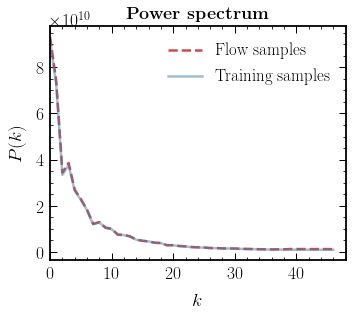

In [26]:
fig, axs = plt.subplots(figsize=(5, 4.5))

plt.plot(np.nanmean(x_pspec_samples, axis=0)[1:], label="Flow samples", ls='--')
plt.plot(np.mean(x_pspec_train, axis=0)[1:], label="Training samples", alpha=0.5)

# plt.fill_between(np.arange(x_pspec_train.shape[-1] - 1), np.percentile(x_pspec_train, [16], axis=0)[0, 1:], np.percentile(x_pspec_train, [84], axis=0)[0, 1:], alpha=0.5, color=cols_default[0])
# plt.fill_between(np.arange(x_pspec_samples.shape[-1] - 1), np.percentile(x_pspec_samples, [16], axis=0)[0, 1:], np.percentile(x_pspec_train, [84], axis=0)[0, 1:], alpha=0.5, color=cols_default[1])

plt.xlabel("$k$")
plt.ylabel("$P(k)$")
plt.title(r"\textbf{Power spectrum}")
         
plt.xlim(0, x_pspec_samples.shape[-1])

plt.legend()

plt.tight_layout()
plt.savefig("../paper/power_spectrum.pdf")

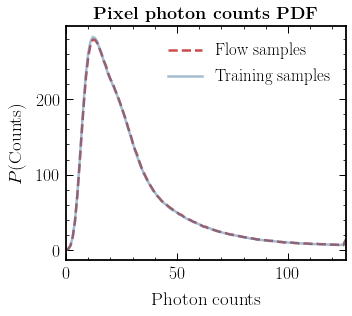

In [27]:
fig, axs = plt.subplots(figsize=(5, 4.5))

plt.plot(np.nanmean(x_hist_samples, axis=0), label="Flow samples", ls='--')
plt.plot(np.mean(x_hist_train, axis=0), label="Training samples", alpha=0.5)

plt.xlabel("Photon counts")
plt.ylabel(r"$P(\mathrm{Counts})$")
plt.title(r"\textbf{Pixel photon counts PDF}")
         
plt.legend()

plt.xlim(0, np.mean(x_hist_train, axis=0).shape[-1]-1)

plt.tight_layout()
plt.savefig("../paper/counts_pdf.pdf")

## Interpolating in the latent space

In [117]:
def z_interp(z1_list, z2_list, weight=0.5):
    z_interp_list = [torch.lerp(z1, z2, weight) for z1, z2 in zip(z1_list, z2_list)]
    return z_interp_list

In [118]:
x0 = x[5:7]
log_p_sum, logdet, z0 = model.flow(x0.to('cuda'))

In [119]:
x_reco = model.flow.reverse(z0, reconstruct=True, quant_int=True)

In [120]:
(x0 - x_reco.cpu() != 0.).sum()

tensor(6)

In [121]:
z_list = [[z00[i].unsqueeze(0) for z00 in z0] for i in range(x0.shape[0])]

In [122]:
vrange = 150

In [28]:
# fig, axs = plt.subplots(figsize=(5, 4))

# plot = plt.imshow(x[66].detach().numpy()[0] * ~mask_roi[2:-2, 2:-2], cmap=cmap, vmax=vrange, extent=[-25,25,-25,25])
# plt.ylabel(r"$l\,[^\circ]$")
# plt.xlabel(r"$b\,[^\circ]$")

# cbar = fig.colorbar(plot, ax=plt.gca(), extend='both')
# cbar.minorticks_on()

# plt.tight_layout()

# plt.savefig("plots/D_test.pdf")

In [148]:
# fig, axs = plt.subplots(figsize=(5, 4))

# plt.imshow(np.random.randn(96, 96), cmap=cmap, extent=[-25,25,-25,25])
# plt.ylabel(r"$l\,[^\circ]$")
# plt.xlabel(r"$b\,[^\circ]$")

# plt.tight_layout()
# plt.savefig("plots/N2.pdf")

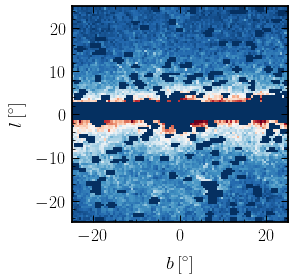

In [146]:
from celluloid import Camera

n_interp = 20

weights_ary = np.linspace(0, 1, n_interp)

fig = plt.figure(figsize=(5,4))

camera = Camera(fig)


for j in range(x0.shape[0] - 1):
    for i in range(n_interp):
        x_dec = model.flow.reverse(z_interp(z_list[j], z_list[j + 1], weight=weights_ary[i]), reconstruct=True, quant_int=True).cpu()
        # plt.imshow(x_dec[0,0].detach().numpy() * ~mask_roi[2:-2, 2:-2], cmap=cmap, vmin=0, vmax=vrange)
        plt.imshow(x_dec[0,0].detach().numpy() * ~mask_roi[2:-2, 2:-2], cmap=cmap, vmin=0, vmax=vrange, extent=[-25,25,-25,25])
        plt.ylabel(r"$l\,[^\circ]$")
        plt.xlabel(r"$b\,[^\circ]$")
        
        plt.tight_layout()

        camera.snap()

In [129]:
animation = camera.animate()

In [130]:
# from IPython.display import HTML
# HTML(animation.to_html5_video())

In [131]:
animation.save('latent_interp.gif', fps=10)

MovieWriter ffmpeg unavailable; using Pillow instead.


## Inference network

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim

import pytorch_lightning as pl
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint, EarlyStopping

In [30]:
from models.resnet_module import ResnetPL

In [31]:
from torch.utils.data import TensorDataset, DataLoader, random_split, SubsetRandomSampler

In [32]:
# x = torch.Tensor(signal_ensemble).unsqueeze(1)
# x = x[:, :, 2:-2, 2:-2] 

In [33]:
y = torch.Tensor(flux_fraction)

In [34]:
y_counts = y * x.mean((-1, -2))

y_mean = y_counts.mean(0)
y_std = y_counts.std(0)

y_counts = (y_counts - y_mean) / y_std

In [35]:
x_mean = 0  # x.mean()
x_std = 1  # x.std()

In [36]:
# x_train = (x - x_mean) / x_std
# y_train = y

In [37]:
val_fraction = 0.10
n_samples_val = int(val_fraction * len(x))

dataset = TensorDataset(x, y_counts)

dataset_train, dataset_val = random_split(dataset, [len(x) - n_samples_val, n_samples_val])
train_loader = DataLoader(dataset_train, batch_size=128, num_workers=2, pin_memory=True, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=128, num_workers=2, pin_memory=True, shuffle=False)

/n/home11/smsharma/.local/lib/python3.8/site-packages/torch/utils/data/dataloader.py:487: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


In [38]:
model_inference = ResnetPL(softmax=False, mask=mask_roi[2:-2, 2:-2])

In [38]:
model_inference.resnet.train();

In [39]:
checkpoint_callback = ModelCheckpoint(monitor="val_loss")
lr_monitor = LearningRateMonitor(logging_interval='epoch')

trainer = pl.Trainer(max_epochs=35, gpus=1, gradient_clip_val=1., callbacks=[checkpoint_callback, lr_monitor])
trainer.fit(model=model_inference, train_dataloaders=train_loader, val_dataloaders=val_loader)

model_inference.load_from_checkpoint(checkpoint_callback.best_model_path, mask=mask_roi[2:-2, 2:-2]);

GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/n/home11/smsharma/.local/lib/python3.8/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:608: UserWarning: Checkpoint directory /net/rcstorenfs02/ifs/rc_labs/dvorkin_lab/smsharma/mi-attribution/notebooks/lightning_logs/version_5656501/checkpoints exists and is not empty.
  rank_zero_warn(f"Checkpoint directory {dirpath} exists and is not empty.")
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name   | Type            | Params
-------------------------------------------
0 | resnet | ResNetEstimator | 12.3 M
1 | loss   | GaussianNLLLoss | 0     
-------------------------------------------
12.3 M    Trainable params
0         Non-trainable params
12.3 M    Total params
49.015    Total estimated model params size (MB)


/n/home11/smsharma/.local/lib/python3.8/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:240: PossibleUserWarning: The dataloader, val_dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 32 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/n/home11/smsharma/.local/lib/python3.8/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:240: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 32 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


In [40]:
model_inference.eval();

In [41]:
torch.save(model_inference.resnet.state_dict(), "../data/resnet.pt")

In [39]:
model_inference.resnet.load_state_dict(torch.load("../data/resnet.pt"))
model_inference.eval();
model_inference.to('cpu');

In [40]:
data = np.load("../data/samples/data_uniform_test.npz")
signal_ensemble = data["signal_ensemble"]
flux_fraction = data["flux_fraction"]

x_test = torch.Tensor(signal_ensemble).unsqueeze(1)
y_test = torch.Tensor(flux_fraction)

x_test = x_test[:, :, 2:-2, 2:-2] 

In [41]:
y_counts_test = y_test * x_test.mean((-1, -2))
y_counts_test = (y_counts_test - y_mean) / y_std

In [42]:
y_true = y_counts_test[:256].detach().numpy()

In [43]:
out = model_inference.resnet(((x_test[:256, 0] + 1e-6).log10() - x_mean) / x_std * ~mask_roi[2:-2, 2:-2])
mu, logvar = torch.chunk(out, 2, -1)
# mu = torch.softmax(mu, dim=-1)

In [44]:
mu

tensor([[ 0.7403, -0.7715, -0.5082,  ...,  0.0567,  1.5596, -0.0527],
        [ 0.4048, -1.3904, -0.1098,  ..., -0.0120, -0.3738, -0.9234],
        [-0.8152,  0.2421, -1.0320,  ..., -0.0058, -0.1565,  0.0311],
        ...,
        [ 0.3946,  0.4906, -0.4050,  ..., -0.0223, -1.5036, -0.0607],
        [-0.4858,  0.6527, -1.4159,  ...,  0.0250,  0.5172, -0.4252],
        [ 0.2951, -0.7497,  0.3303,  ...,  0.0481,  0.4446, -0.1484]],
       grad_fn=<SplitBackward0>)

In [45]:
labels = ["GCE PS", "Disk PS", "GCE DM", "Iso", "Bub", "3FGL PS", r"$\pi^0$+brem", "ICS"]

100%|██████████| 8/8 [00:00<00:00, 50.81it/s]


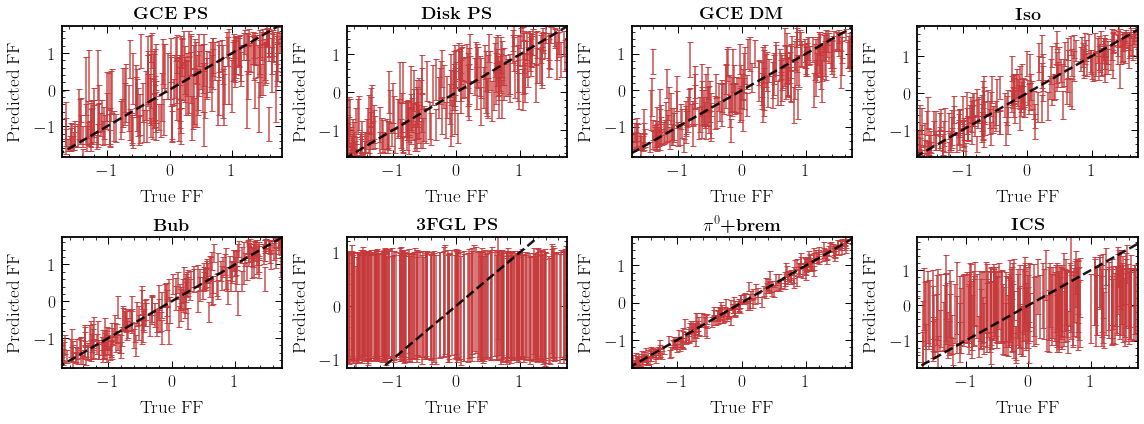

In [46]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(16, 6))
gs = GridSpec(2, 4)

for i in tqdm(range(8)):
    
    ax = fig.add_subplot(gs[i])
    ax.errorbar(y_true[:, i], mu[:, i].detach().numpy(), yerr=logvar[:, i].exp().sqrt().detach().numpy(), fmt='none', capsize=3, capthick=1, elinewidth=1.5)
    ax.plot([-3., 3],[-3, 3], ls='--', color='k')
    
    ax.set_xlim(np.min(y_true[:, i]), np.max(y_true[:, i]))
    ax.set_ylim(np.min(mu[:, i].detach().numpy() - logvar[:, i].exp().sqrt().detach().numpy()), np.max(mu[:, i].detach().numpy() + logvar[:, i].exp().sqrt().detach().numpy()))
    
    ax.set_title(r"\textbf{" + labels[i] + "}")
    
    ax.set_xlabel("True FF")
    ax.set_ylabel("Predicted FF")
    
plt.tight_layout()

## Counterfactuals

In [47]:
from torch.autograd.functional import vjp, jvp, jacobian

In [48]:
model.to('cuda');
model_inference.to('cuda');

In [49]:
class DiffeomorphicCounterfactual(torch.nn.Module):
    def __init__(self, z0):
        """
        In the constructor we instantiate four parameters and assign them as
        member parameters.
        """
        super().__init__()
        self.z = torch.nn.ParameterList(z0).to('cuda')

    def forward(self):
        """
        In the forward function we accept a Tensor of input data and we must return
        a Tensor of output data. We can use Modules defined in the constructor as
        well as arbitrary operators on Tensors.
        """
        reco = model.flow.reverse(self.z, reconstruct=True, quant_int=False) + 1e-6
        # return torch.softmax(model_inference.resnet((reco.log10())[0] * torch.Tensor(~mask_roi[2:-2, 2:-2]).to('cuda'))[:, :8], dim=-1)
        return (model_inference.resnet((reco.log10())[0] * torch.Tensor(~mask_roi[2:-2, 2:-2]).to('cuda'))[:, :8])

In [50]:
idx_test = 66

In [51]:
out = model_inference.resnet((torch.Tensor(x_test[idx_test] + 1e-6).log10() * torch.Tensor(~mask_roi[2:-2, 2:-2])).to('cuda'))
mu, logvar = torch.chunk(out, 2, -1)
# mu = torch.softmax(mu, dim=-1)

print(mu.cpu())
print(logvar.exp().sqrt().cpu())

tensor([[-1.0069,  0.4958, -0.5766,  0.4952, -0.7157, -0.0367, -0.1415,  0.2234]],
       grad_fn=<ToCopyBackward0>)
tensor([[0.4682, 0.4915, 0.3881, 0.3458, 0.2738, 1.0086, 0.1195, 0.9705]],
       grad_fn=<ToCopyBackward0>)


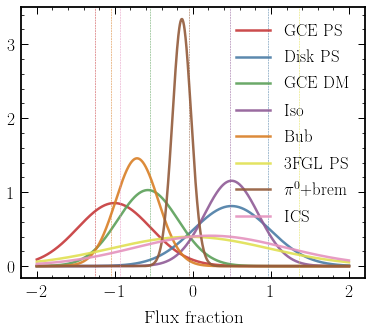

In [52]:
from scipy.stats import norm

x_ary = np.linspace(-2, 2, 1000)

for i in range(8):
    plt.plot(x_ary, norm.pdf(x_ary, mu[0, i].cpu().detach().numpy(), logvar.exp().sqrt()[0, i].cpu().detach().numpy()), label=labels[i], color=cols_default[i])
    plt.axvline(y_counts_test[idx_test][i], color=cols_default[i], ls='--', lw=0.5)
    
plt.xlabel(r"Flux fraction")
# plt.xlim(0, .20)
plt.legend()

In [53]:
class GenerateCounterfactuals:
    def __init__(self, x0, model_gen, model_inf, sigma=1.):
        
        log_p_sum, logdet, z0 = model.flow(x0.to('cuda'))
        out = model_inf.resnet(((x0[0] + 1e-6).log10() * torch.Tensor(~mask_roi[2:-2, 2:-2])).to('cuda'))
        self.mu, self.logvar = torch.chunk(out, 2, -1)
        # self.mu = torch.softmax(self.mu, dim=-1)
        
        print(self.mu)
        print(self.logvar.exp().sqrt())
        
        self.sigma = sigma
        
        self.z0 = z0
        
    def generate_counterfactual(self, i_param=0, cf_type=1, lr=0.1, print_every=10):
        
        z0_param = [nn.Parameter(zz.to('cuda')) for zz in self.z0.copy()]
        dc = DiffeomorphicCounterfactual(z0_param).to('cuda')
        
        optimizer = torch.optim.SGD(dc.parameters(), lr=lr)

        i = 0
        
        condition = True
        
        while condition:

            if cf_type == -1:
                y_preds = dc()
            elif cf_type == 1:
                y_preds = -dc()
            else:
                raise NotImplementedError
                
            y_pred = y_preds[0, i_param]
            idx_others = torch.arange(8)[torch.arange(8) != i_param]
            
            delta_others = (self.mu - y_preds)[0, idx_others]# ** 2
            
            loss = y_pred + delta_others.abs().mean()#.sqrt()
                        
            optimizer.zero_grad()
            loss.backward(retain_graph=True)
            optimizer.step()
            
            x_cf_temp = model.flow.reverse(dc.z, reconstruct=True, quant_int=False, quant_type='round')
            y_pred_quant = model_inference.resnet(((x_cf_temp + 1e-6).log10()[0] * torch.Tensor(~mask_roi[2:-2, 2:-2]).to('cuda')))[0, i_param]
            if i % print_every == 0:
                print(y_pred_quant)

            if cf_type == -1:
                condition = y_pred_quant > (self.mu - self.sigma * self.logvar.exp().sqrt())[0, i_param]
            elif cf_type == 1:
                condition = -y_pred_quant > -(self.mu + self.sigma * self.logvar.exp().sqrt())[0, i_param]
            else:
                raise NotImplementedError

            i += 1
            
        z_cf = dc.z
        x_cf = model.flow.reverse(dc.z, reconstruct=True, quant_int=False, quant_type='round')[0,0].cpu().detach().numpy()
            
        return x_cf, z_cf

In [54]:
x_cf = np.zeros((10, 8, 96, 96))

In [55]:
from tqdm import tqdm

In [56]:
for i_test in tqdm(range(2)):
    for i_comp in range(8):
        if i_comp == 5:
            continue
        print("Computing counterfactual for {}".format(i_comp))
        x0 = x_test[i_test].unsqueeze(0)
        gc = GenerateCounterfactuals(x0, model_gen=model, model_inf=model_inference, sigma=1.)
        # if gc.mu[0, i_comp] < 0.01:
        #     continue
        x_cf[i_test, i_comp], z_cf = gc.generate_counterfactual(i_param=i_comp, cf_type=-1, lr=1e-1, print_every=10)

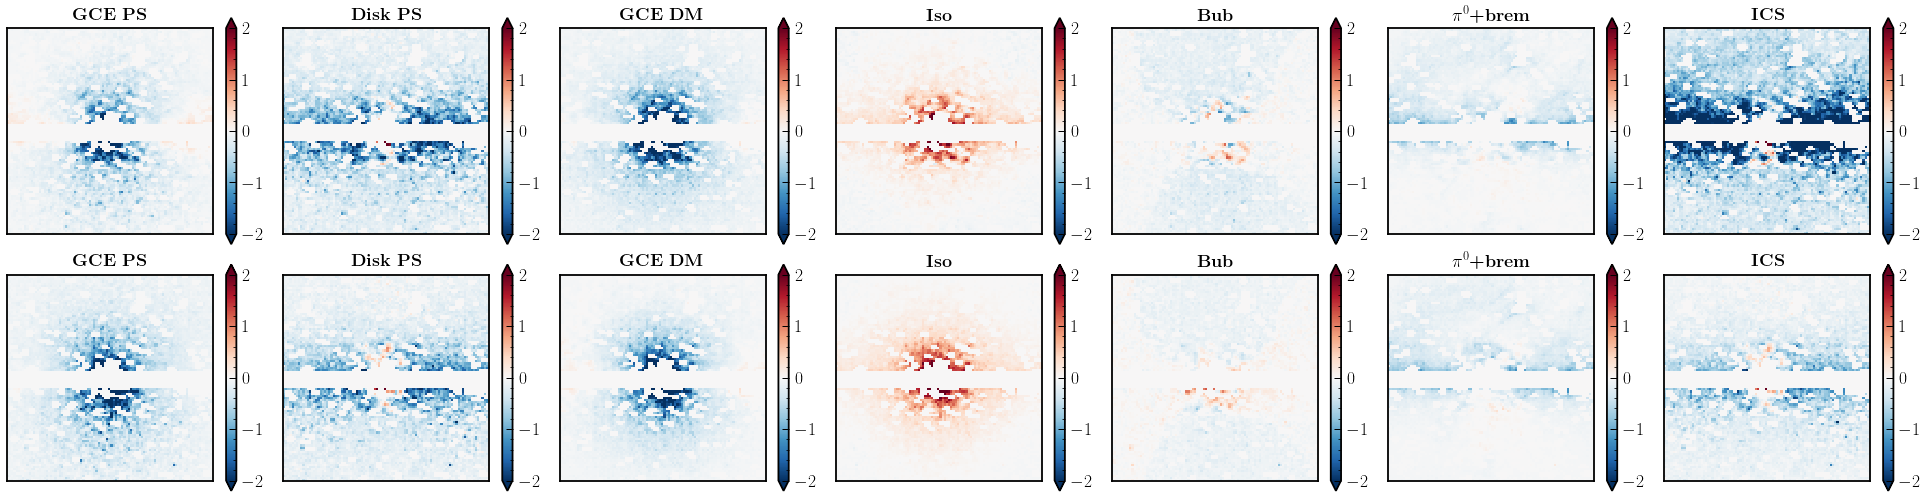

In [112]:
n_sim = 2
fig, axs = plt.subplots(n_sim, 7, figsize=(27, 3.5 * n_sim))
vrange = 100
vrange = 2

for i_sim in range(n_sim):
    for i_comp, idx_comp in enumerate([0,1,2,3,4,6,7]):

        plot = axs[i_sim, i_comp].imshow((x_cf[i_sim, idx_comp] - x_test[i_sim, 0].detach().numpy()) * ~mask_roi[2:-2, 2:-2], cmap=cmap, vmin=-vrange, vmax=vrange, origin='lower')
        axs[i_sim, i_comp].set_title(r"\textbf{" + labels[idx_comp] + "}")
        axs[i_sim, i_comp].get_xaxis().set_visible(False)
        axs[i_sim, i_comp].get_yaxis().set_visible(False)

        cbar = fig.colorbar(plot, ax=axs[i_sim, i_comp], extend='both')
        cbar.minorticks_on()


plt.tight_layout()
plt.savefig("../paper/counterfactuals_grid.pdf")

In [171]:
# fig, axs = plt.subplots(3, 3, figsize=(10 * 1.5, 10 * 1.5))
# vrange = 100

# for i_comp, idx_comp in enumerate([0,1,3]):

#     axs[i_comp, 0].imshow(x0[0,0].detach().numpy() * ~mask_roi[2:-2, 2:-2], cmap=cmap, vmin=0, vmax=vrange, origin='lower')
#     axs[i_comp, 0].set_title(r"\bf{Original}")

#     axs[i_comp, 1].imshow(x_cf[idx_comp] * ~mask_roi[2:-2, 2:-2], cmap=cmap, vmin=0, vmax=vrange, origin='lower')
#     axs[i_comp, 1].set_title(r"\bf{Counterfactual, " + labels[i_comp] + "}")

#     axs[i_comp, 2].imshow((x_cf[idx_comp] - x0[0,0].detach().numpy()) * ~mask_roi[2:-2, 2:-2], cmap=cmap, vmin=-5, vmax=5, origin='lower')
#     axs[i_comp, 2].set_title(r"\bf{Difference}")
    
#     axs[i_comp, 2].get_xaxis().set_visible(False)
#     axs[i_comp, 2].get_yaxis().set_visible(False)


In [162]:
np.save("../data/x_cf.npy", x_cf)

In [41]:
x_cf = np.load("../data/x_cf.npy")

In [278]:
out = model_inference.resnet((torch.Tensor(x_test[2] + 1e-6).log10() * torch.Tensor(~mask_roi[2:-2, 2:-2])).to('cuda'))
mu, logvar = torch.chunk(out, 2, -1)
# mu = torch.softmax(mu, dim=-1)

print(mu.cpu())
print(logvar.exp().sqrt().cpu())

tensor([[-0.6765,  0.3616, -1.2190, -0.9762,  0.5054,  0.0359, -0.0342, -0.2203]],
       grad_fn=<ToCopyBackward0>)
tensor([[0.4838, 0.4904, 0.3094, 0.3158, 0.2751, 0.9916, 0.1229, 0.9928]],
       grad_fn=<ToCopyBackward0>)


In [279]:
out = model_inference.resnet((torch.Tensor(x_cf[2, 0] + 1e-6).log10().unsqueeze(0) * torch.Tensor(~mask_roi[2:-2, 2:-2])).to('cuda'))
mu, logvar = torch.chunk(out, 2, -1)
# mu = torch.softmax(mu, dim=-1)

print(mu.cpu())
print(logvar.exp().sqrt().cpu())

tensor([[-1.1625,  0.5824, -1.3214, -0.7346,  0.6384,  0.0363, -0.0374, -0.2148]],
       grad_fn=<ToCopyBackward0>)
tensor([[0.3589, 0.4615, 0.2318, 0.3173, 0.2686, 0.9959, 0.1219, 0.9629]],
       grad_fn=<ToCopyBackward0>)


In [281]:
out = model_inference.resnet((torch.Tensor(x_cf[2, 1] + 1e-6).log10().unsqueeze(0) * torch.Tensor(~mask_roi[2:-2, 2:-2])).to('cuda'))
mu, logvar = torch.chunk(out, 2, -1)
# mu = torch.softmax(mu, dim=-1)

print(mu.cpu())
print(logvar.exp().sqrt().cpu())

tensor([[-0.3446, -0.1821, -0.8504, -1.3624,  0.4087,  0.0107,  0.1930, -0.0768]],
       grad_fn=<ToCopyBackward0>)
tensor([[0.6204, 0.5341, 0.4466, 0.2160, 0.2711, 1.0127, 0.1484, 1.0181]],
       grad_fn=<ToCopyBackward0>)


## 2-counterfactuals

In [110]:
class Generate2Counterfactuals:
    def __init__(self, x0, model_gen, model_inf, sigma=1.):
        
        log_p_sum, logdet, z0 = model.flow(x0.to('cuda'))
        out = model_inf.resnet(((x0[0] + 1e-6).log10() * torch.Tensor(~mask_roi[2:-2, 2:-2])).to('cuda'))
        self.mu, self.logvar = torch.chunk(out, 2, -1)
        # self.mu = torch.softmax(self.mu, dim=-1)
        
        print(self.mu)
        print(self.logvar.exp().sqrt())
        
        self.sigma = sigma
        
        self.z0 = z0
        
    def generate_counterfactual(self, i_param_1=0, i_param_2=2, lr=0.1, print_every=10):
        
        z0_param = [nn.Parameter(zz.to('cuda')) for zz in self.z0.copy()]
        dc = DiffeomorphicCounterfactual(z0_param).to('cuda')
        
        optimizer = torch.optim.SGD(dc.parameters(), lr=lr)

        i = 0
        
        condition = True
        
        while condition:

            y_preds = dc()
                
            delta_y = y_preds[0, i_param_1] - y_preds[0, i_param_2]
            idx_others = torch.arange(8)[(torch.arange(8) != i_param_1) * (torch.arange(8) != i_param_2)]
            delta_others = (self.mu - y_preds)[0, idx_others]
            
            loss = delta_y.abs() + delta_others.abs().mean()
                        
            optimizer.zero_grad()
            loss.backward(retain_graph=True)
            optimizer.step()
            
            x_cf_temp = model.flow.reverse(dc.z, reconstruct=True, quant_int=False, quant_type='round')
            y_pred_quant = model_inference.resnet(((x_cf_temp + 1e-6).log10()[0] * torch.Tensor(~mask_roi[2:-2, 2:-2]).to('cuda')))
            delta_y_quant = y_pred_quant[0, i_param_1] - y_pred_quant[0, i_param_2]
            
            if i % print_every == 0:
                print(delta_y_quant.abs(), y_pred_quant)

            condition = delta_y_quant.abs()  > 0.1

            i += 1
            
        # print("Final", model_inference.resnet(((x_cf_temp + 1e-6).log10()[0] * torch.Tensor(~mask_roi[2:-2, 2:-2]).to('cuda'))))

        z_cf = dc.z
        x_cf = model.flow.reverse(dc.z, reconstruct=True, quant_int=False, quant_type='round')[0,0].cpu().detach().numpy()
        
        return x_cf, z_cf

In [111]:
x_cf = np.zeros((10, 96, 96))

In [57]:
for i_test in tqdm(range(5)):
    x0 = x_test[i_test].unsqueeze(0)
    gc = Generate2Counterfactuals(x0, model_gen=model, model_inf=model_inference, sigma=1.)
    x_cf[i_test], z_cf = gc.generate_counterfactual(i_param_1=0, i_param_2=2, lr=1e-1, print_every=10)

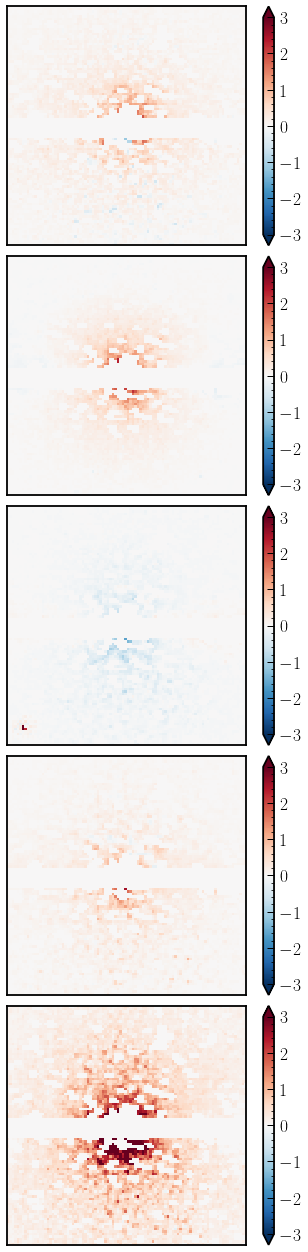

In [113]:
n_sim = 5
fig, axs = plt.subplots(n_sim, figsize=(5, 3.5 * n_sim))
vrange = 100
vrange = 3

for i_sim in range(n_sim):

    plot = axs[i_sim].imshow((x_cf[i_sim] - x_test[i_sim, 0].detach().numpy()) * ~mask_roi[2:-2, 2:-2], cmap=cmap, vmin=-vrange, vmax=vrange, origin='lower')
    # axs[i_sim].set_title(r"\textbf{" + labels[idx_comp] + "}")
    axs[i_sim].get_xaxis().set_visible(False)
    axs[i_sim].get_yaxis().set_visible(False)

    cbar = fig.colorbar(plot, ax=axs[i_sim], extend='both')
    cbar.minorticks_on()


plt.tight_layout()
# plt.savefig("plots/counterfactuals_grid.pdf")

In [114]:
out = model_inference.resnet((torch.Tensor(x_test[0] + 1e-6).log10() * torch.Tensor(~mask_roi[2:-2, 2:-2])).to('cuda'))
mu, logvar = torch.chunk(out, 2, -1)
# mu = torch.softmax(mu, dim=-1)

print(mu.cpu())
print(logvar.exp().sqrt().cpu())

tensor([[ 0.7403, -0.7715, -0.5082,  0.7940,  0.1782,  0.0567,  1.5596, -0.0527]],
       grad_fn=<ToCopyBackward0>)
tensor([[0.5497, 0.4948, 0.4247, 0.3794, 0.3308, 0.9800, 0.1024, 0.9241]],
       grad_fn=<ToCopyBackward0>)


In [115]:
out = model_inference.resnet((torch.Tensor(x_cf[0] + 1e-6).log10().unsqueeze(0) * torch.Tensor(~mask_roi[2:-2, 2:-2])).to('cuda'))
mu, logvar = torch.chunk(out, 2, -1)
# mu = torch.softmax(mu, dim=-1)

print(mu.cpu())
print(logvar.exp().sqrt().cpu())

tensor([[ 0.1170, -0.7104,  0.1025,  0.7317,  0.1614,  0.0556,  1.5527, -0.0116]],
       grad_fn=<ToCopyBackward0>)
tensor([[0.6775, 0.4955, 0.5012, 0.3778, 0.3241, 0.9782, 0.1040, 0.9762]],
       grad_fn=<ToCopyBackward0>)


## Adversarial counterfactuals

In [74]:
class AdversarialCounterfactual(torch.nn.Module):
    def __init__(self, x0):
        """
        In the constructor we instantiate four parameters and assign them as
        member parameters.
        """
        super().__init__()
        self.x = nn.Parameter(x0.to('cuda'))

    def forward(self):
        """
        In the forward function we accept a Tensor of input data and we must return
        a Tensor of output data. We can use Modules defined in the constructor as
        well as arbitrary operators on Tensors.
        """
        return (model_inference.resnet((self.x.log10())[0] * torch.Tensor(~mask_roi[2:-2, 2:-2]).to('cuda'))[:, :8])

In [81]:
class GenerateAdversarialCounterfactuals:
    def __init__(self, x0, model_inf, sigma=1.):
        
        out = model_inf.resnet(((x0[0] + 1e-6).log10() * torch.Tensor(~mask_roi[2:-2, 2:-2])).to('cuda'))
        self.mu, self.logvar = torch.chunk(out, 2, -1)
        # self.mu = torch.softmax(self.mu, dim=-1)
        
        print(self.mu)
        print(self.logvar.exp().sqrt())
        
        self.sigma = sigma
        
        self.x0 = x0
        
    def generate_counterfactual(self, i_param=0, cf_type=1, lr=0.1, print_every=10):
                
        ac = AdversarialCounterfactual(self.x0).to('cuda')
        optimizer = torch.optim.SGD(ac.parameters(), lr=lr)

        i = 0
        
        condition = True
        
        while condition:
            
            out = ac()

            if cf_type == -1:
                y_pred = out[0, i_param]
            elif cf_type == 1:
                y_pred = -out[0, i_param]
            else:
                raise NotImplementedError
                            
            loss = y_pred
                        
            optimizer.zero_grad()
            loss.backward(retain_graph=True)
            optimizer.step()
            
            if i % print_every == 0:
                print(y_pred)

            if cf_type == -1:
                condition = y_pred > (self.mu - self.sigma * self.logvar.exp().sqrt())[0, i_param]
            elif cf_type == 1:
                condition = -y_pred > -(self.mu + self.sigma * self.logvar.exp().sqrt())[0, i_param]
            else:
                raise NotImplementedError

            i += 1
                        
        return ac.x

In [82]:
for i_test in tqdm(range(2)):
    for i_comp in range(8):
        if i_comp == 5:
            continue
        print("Computing counterfactual for {}".format(i_comp))
        x0 = x_test[i_test].unsqueeze(0)
        gc = GenerateAdversarialCounterfactuals(x0, model_inf=model_inference, sigma=1.)
        x_cf[i_test, i_comp] = gc.generate_counterfactual(i_param=i_comp, cf_type=-1, lr=1e-1, print_every=10).cpu().detach().numpy()

  0%|          | 0/2 [00:00<?, ?it/s]

Computing counterfactual for 0
tensor([[ 0.7403, -0.7715, -0.5082,  0.7940,  0.1782,  0.0567,  1.5596, -0.0527]],
       device='cuda:0', grad_fn=<SplitBackward0>)
tensor([[0.5497, 0.4948, 0.4247, 0.3794, 0.3308, 0.9800, 0.1024, 0.9241]],
       device='cuda:0', grad_fn=<SqrtBackward0>)
tensor(0.7403, device='cuda:0', grad_fn=<SelectBackward0>)
tensor(0.7218, device='cuda:0', grad_fn=<SelectBackward0>)
tensor(0.7029, device='cuda:0', grad_fn=<SelectBackward0>)
tensor(0.6836, device='cuda:0', grad_fn=<SelectBackward0>)
tensor(0.6634, device='cuda:0', grad_fn=<SelectBackward0>)
tensor(0.6430, device='cuda:0', grad_fn=<SelectBackward0>)
tensor(0.6222, device='cuda:0', grad_fn=<SelectBackward0>)
tensor(0.6008, device='cuda:0', grad_fn=<SelectBackward0>)
tensor(0.5791, device='cuda:0', grad_fn=<SelectBackward0>)
tensor(0.5573, device='cuda:0', grad_fn=<SelectBackward0>)
tensor(0.5357, device='cuda:0', grad_fn=<SelectBackward0>)
tensor(0.5129, device='cuda:0', grad_fn=<SelectBackward0>)
tens

 50%|█████     | 1/2 [01:16<01:16, 76.92s/it]

tensor(-0.9702, device='cuda:0', grad_fn=<SelectBackward0>)
tensor(-0.9717, device='cuda:0', grad_fn=<SelectBackward0>)
tensor(-0.9733, device='cuda:0', grad_fn=<SelectBackward0>)
tensor(-0.9749, device='cuda:0', grad_fn=<SelectBackward0>)
tensor(-0.9765, device='cuda:0', grad_fn=<SelectBackward0>)
Computing counterfactual for 0
tensor([[ 0.4048, -1.3904, -0.1098,  0.7692,  1.2135, -0.0120, -0.3738, -0.9234]],
       device='cuda:0', grad_fn=<SplitBackward0>)
tensor([[0.5820, 0.2326, 0.4592, 0.3131, 0.2579, 1.0271, 0.1246, 0.5264]],
       device='cuda:0', grad_fn=<SqrtBackward0>)
tensor(0.4048, device='cuda:0', grad_fn=<SelectBackward0>)
tensor(0.3872, device='cuda:0', grad_fn=<SelectBackward0>)
tensor(0.3706, device='cuda:0', grad_fn=<SelectBackward0>)
tensor(0.3546, device='cuda:0', grad_fn=<SelectBackward0>)
tensor(0.3382, device='cuda:0', grad_fn=<SelectBackward0>)
tensor(0.3215, device='cuda:0', grad_fn=<SelectBackward0>)
tensor(0.3045, device='cuda:0', grad_fn=<SelectBackward0>)

100%|██████████| 2/2 [02:24<00:00, 72.29s/it]


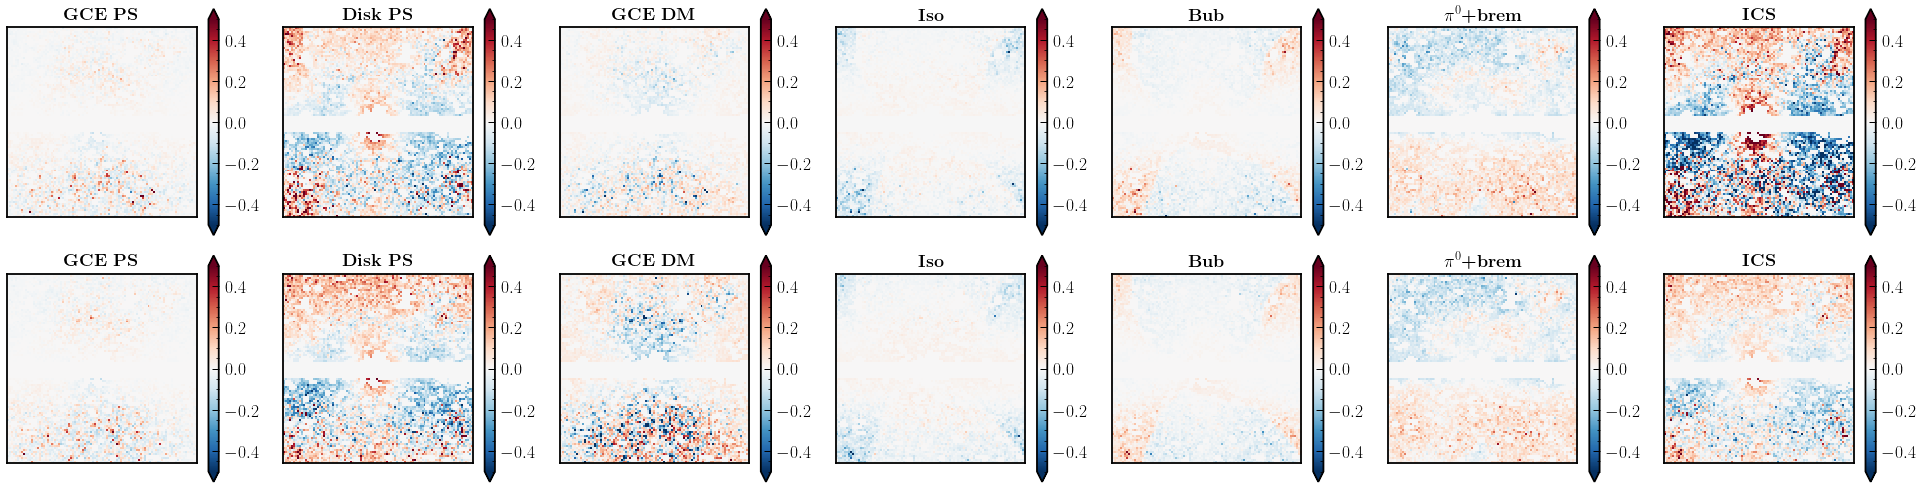

In [85]:
n_sim = 2
fig, axs = plt.subplots(n_sim, 7, figsize=(27, 3.5 * n_sim))
vrange = 100
vrange = 0.5

for i_sim in range(n_sim):
    for i_comp, idx_comp in enumerate([0,1,2,3,4,6,7]):

        plot = axs[i_sim, i_comp].imshow((x_cf[i_sim, idx_comp] - x_test[i_sim, 0].detach().numpy()) * ~mask_roi[2:-2, 2:-2], cmap=cmap, vmin=-vrange, vmax=vrange, origin='lower')
        axs[i_sim, i_comp].set_title(r"\textbf{" + labels[idx_comp] + "}")
        axs[i_sim, i_comp].get_xaxis().set_visible(False)
        axs[i_sim, i_comp].get_yaxis().set_visible(False)

        cbar = fig.colorbar(plot, ax=axs[i_sim, i_comp], extend='both')
        cbar.minorticks_on()


plt.tight_layout()
# plt.savefig("../paper/counterfactuals_grid.pdf")

## Integrated gradients test

In [310]:
from captum.attr import IntegratedGradients

In [311]:
model_inference.to('cuda')
ig = IntegratedGradients(model_inference.resnet)

In [312]:
x_ig = np.zeros((8, 96, 96))

In [314]:
# baseline = (torch.ones((1, 96, 96))).to('cuda')
# baseline = (torch.zeros((1, 96, 96))).to('cuda')
baseline = (x_test[4].log10().to('cuda') + 1e-6) * torch.Tensor(~mask_roi[2:-2, 2:-2]).mean() * (torch.ones((1, 96, 96))).to('cuda')  # Take baseline to be mean input

for i in range(8):
    attributions, approximation_error = ig.attribute((x_test[3].log10().to('cuda') + 1e-6) * torch.Tensor(~mask_roi[2:-2, 2:-2]).to('cuda'),
                                        target=i,
                                        baselines=baseline,
                                        n_steps=1000,
                                        # method='gausslegendre',
                                        return_convergence_delta=True)
    
    x_ig[i] = attributions[0].cpu().detach().numpy()

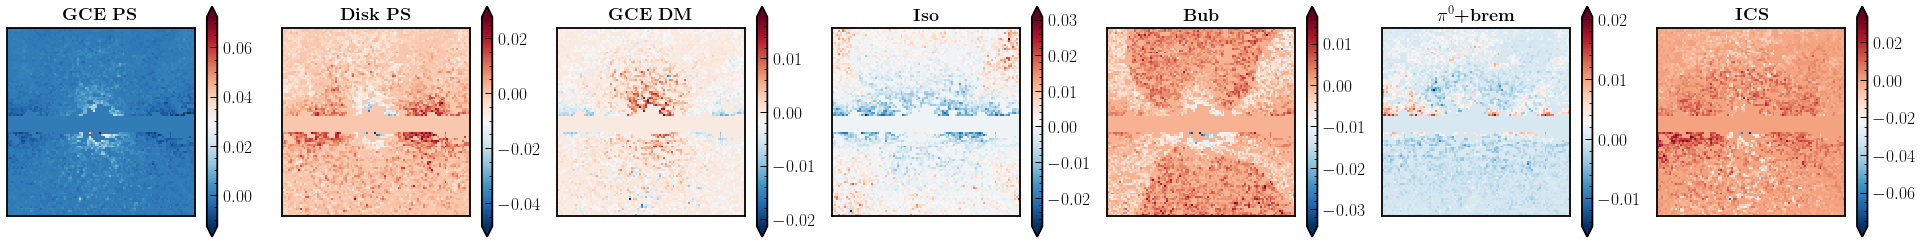

In [315]:
fig, axs = plt.subplots(1, 7, figsize=(27, 3.5))
vrange = 100

for i_comp, idx_comp in enumerate([0,1,2,3,4,6,7]):

    plot = axs[i_comp].imshow((x_ig[idx_comp]) * ~mask_roi[2:-2, 2:-2], cmap=cmap, origin='lower')
    axs[i_comp].set_title(r"\textbf{" + labels[idx_comp] + "}")
    axs[i_comp].get_xaxis().set_visible(False)
    axs[i_comp].get_yaxis().set_visible(False)
    
    cbar = fig.colorbar(plot, ax=axs[i_comp], extend='both')
    cbar.minorticks_on()


plt.tight_layout()

## Real data (dragons)

In [ ]:
out = model_inference.resnet((torch.Tensor(x_test[4] + 1e-6).log10() * torch.Tensor(~mask_roi[2:-2, 2:-2])).to('cuda'))
mu, logvar = torch.chunk(out, 2, -1)
mu = torch.softmax(mu, dim=-1)

mu

In [ ]:
out = model_inference.resnet((torch.Tensor(x_cf[2] + 1e-6).log10().unsqueeze(0) * torch.Tensor(~mask_roi[2:-2, 2:-2])).to('cuda'))
mu, logvar = torch.chunk(out, 2, -1)
mu = torch.softmax(mu, dim=-1)

mu

In [54]:
from astropy.io import fits

counts_fits = fits.open("/n/holyscratch01/iaifi_lab/yitians/ccube_ultracleanveto_bestpsf_joined.fits")

pixel_size_data = 0.1
pixel_size_target = 0.5
extent = 25
i_e = 40

upsample_factor = int(pixel_size_target / pixel_size_data)

counts = counts_fits[0].data[i_e:i_e + 11].sum(0)[int((90 - extent) / 0.1):int((90 + extent) / 0.1),int((90 - extent) / 0.1):int((90 + extent) / 0.1)]
b = counts.shape[0] // upsample_factor
counts_downsampled = counts.reshape(-1, upsample_factor, b, upsample_factor).sum((-1, -3))

In [106]:
x_data = torch.Tensor(counts_downsampled)[2:-2, 2:-2].unsqueeze(0).unsqueeze(0)

x_data[x_data > 100] = 100


In [107]:
_, _, z = model.flow(x_data.to('cuda'))

In [109]:
reco = model.flow.reverse([zzz.to('cuda') for zzz in z.copy()], reconstruct=True, quant_int=False) + 1e-6
reco

tensor([[[[14.0015,  5.0015,  7.0016,  ...,  7.0014, 11.0014,  7.0014],
          [48.0014, 10.0015,  6.0015,  ...,  4.0015,  5.0014,  7.0014],
          [12.0015, 13.0015,  9.0014,  ...,  5.0015, 13.0014,  5.0014],
          ...,
          [13.0015, 10.0015, 18.0014,  ..., 15.0014,  8.0015, 13.0015],
          [ 6.0015,  6.0015,  6.0015,  ..., 18.0015,  7.0015, 12.0015],
          [ 6.0015,  6.0015, 10.0015,  ..., 12.0014, 10.0015,  6.0015]]]],
       device='cuda:0', grad_fn=<AddBackward0>)

In [110]:
model.to('cuda');

In [85]:
for i_comp in range(8):
    if i_comp == 5:
        continue
    print("Computing counterfactual for {}".format(i_comp))
    x0 = x_data
#     x0 = x_test[3].unsqueeze(0)
    gc = GenerateCounterfactuals(x0, model_gen=model, model_inf=model_inference)
    x_cf[i_comp], z_cf = gc.generate_counterfactual(i_param=i_comp, cf_type=1, lr=1e-3, print_every=10)

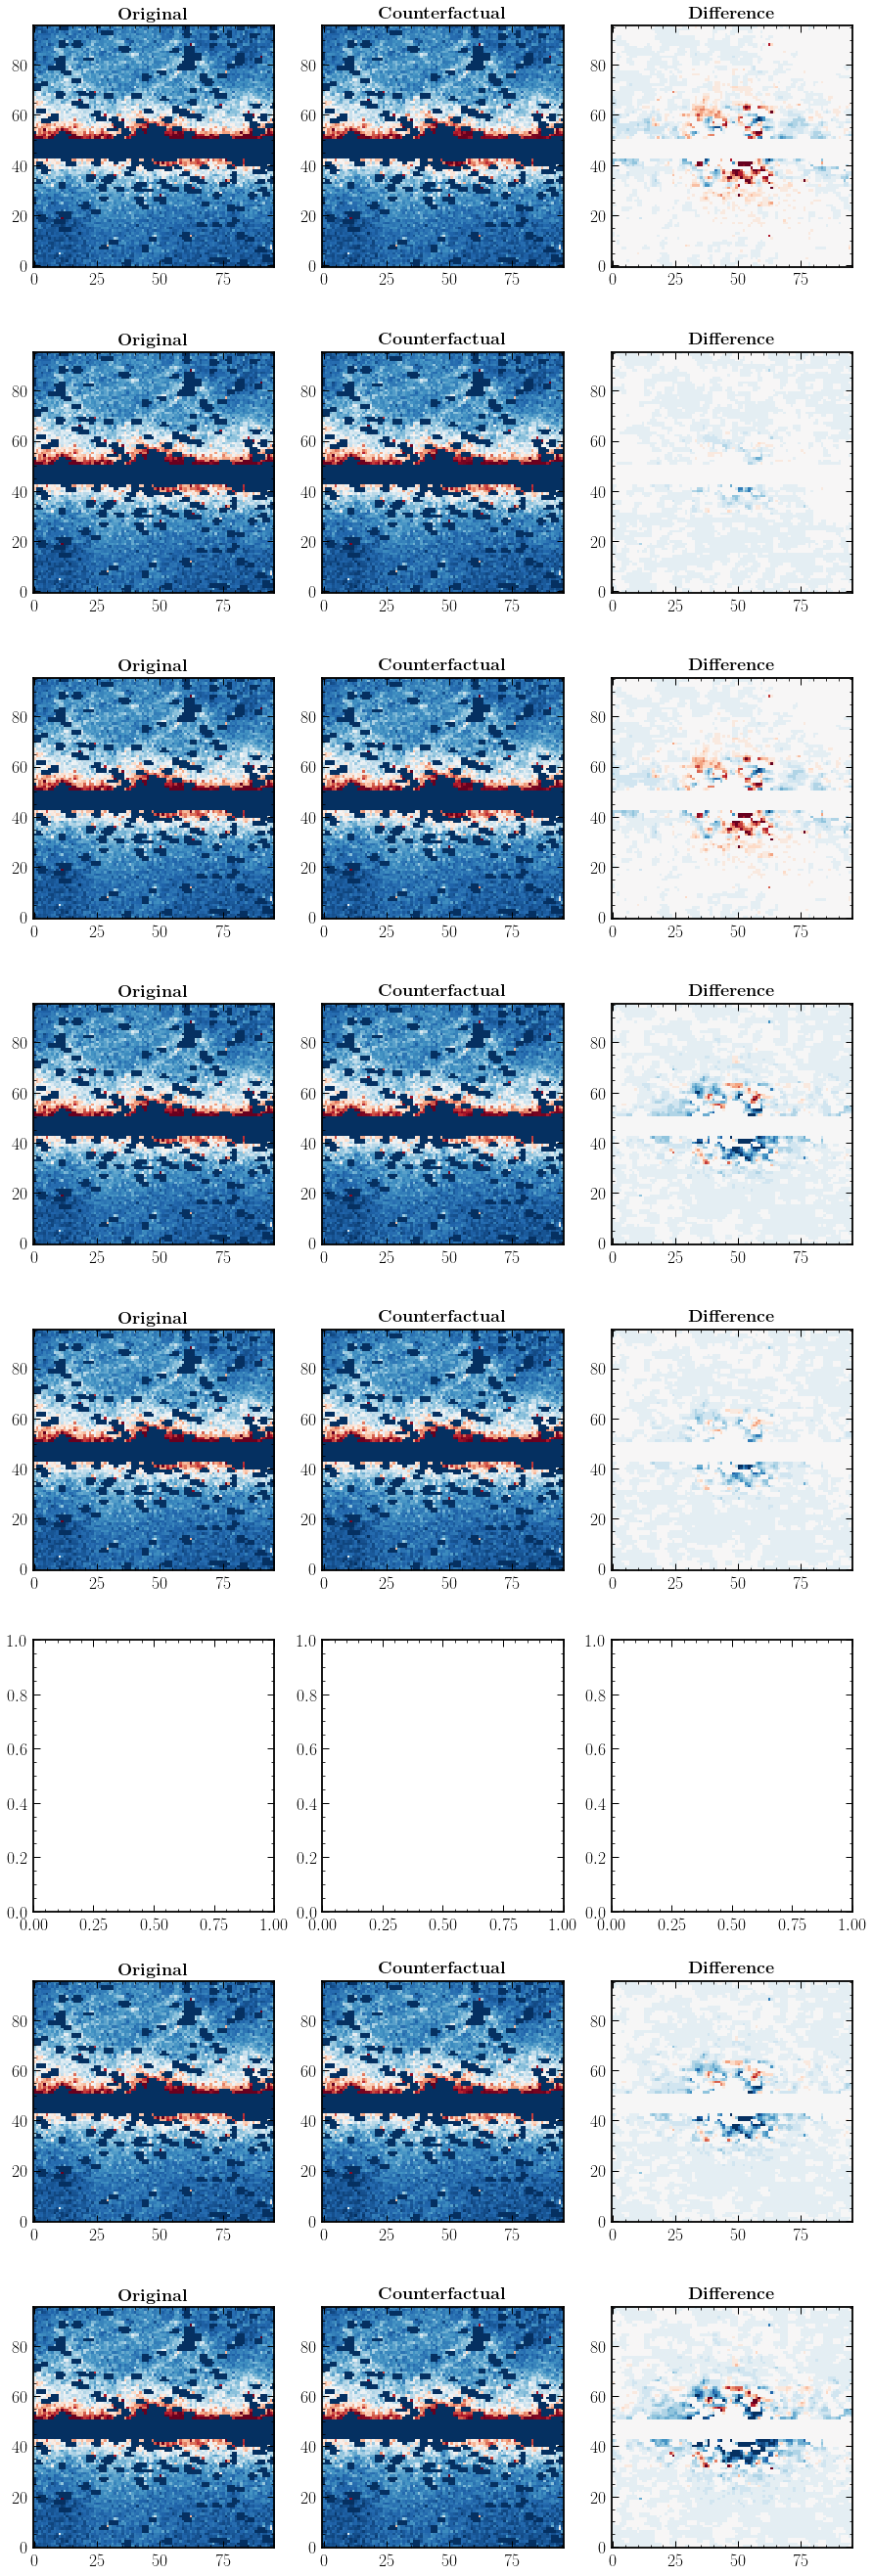

In [112]:
fig, axs = plt.subplots(8, 3, figsize=(10 * 1.5, 32 * 1.5))
vrange = 100

for i_comp, idx_comp in enumerate([0,1,2,3,4, 6,7]):

    axs[idx_comp, 0].imshow(x0[0,0].detach().numpy() * ~mask_roi[2:-2, 2:-2], cmap=cmap, vmin=0, vmax=vrange, origin='lower')
    axs[idx_comp, 0].set_title(r"\bf{Original}")

    axs[idx_comp, 1].imshow(x_cf[idx_comp] * ~mask_roi[2:-2, 2:-2], cmap=cmap, vmin=0, vmax=vrange, origin='lower')
    axs[idx_comp, 1].set_title(r"\bf{Counterfactual}")

    axs[idx_comp, 2].imshow((x_cf[idx_comp] - x0[0,0].detach().numpy()) * ~mask_roi[2:-2, 2:-2], cmap=cmap, vmin=-10, vmax=10, origin='lower')
    axs[idx_comp, 2].set_title(r"\bf{Difference}")

In [ ]:
# fig, axs = plt.subplots(1, 3, figsize=(10 * 1.5, 3 * 1.5))
# vrange = 100

# axs[0].imshow(x0[0,0].detach().numpy() * ~mask_roi[2:-2, 2:-2], cmap=cmap, vmin=0, vmax=vrange, origin='lower')
# axs[0].set_title(r"\bf{Original}")

# axs[1].imshow(x_cf * ~mask_roi[2:-2, 2:-2], cmap=cmap, vmin=0, vmax=vrange, origin='lower')
# axs[1].set_title(r"\bf{Counterfactual}")

# axs[2].imshow((x_cf - x0[0,0].detach().numpy()) * ~mask_roi[2:-2, 2:-2], cmap=cmap, vmin=-5, vmax=5, origin='lower')
# axs[2].set_title(r"\bf{Difference}")

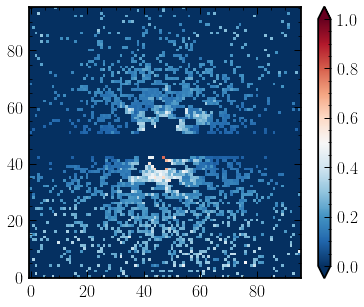

In [299]:
fig, ax = plt.subplots()

plot = plt.imshow(np.abs(x_cf[0] - x0[0,0].detach().numpy()) / np.sqrt(x0[0,0].detach().numpy()) * ~mask_roi[2:-2, 2:-2], cmap=cmap, vmin=0, vmax=1, origin='lower')

cbar = fig.colorbar(plot, ax=plt.gca(), extend='both')
cbar.minorticks_on()
plt.show()